# Project 2 Milestone 2
## The Biomechanics of Basketball Injuries

In [46]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Open the file

basketball_df = pd.read_csv(
    "C:/Users/rmtol/OneDrive/Desktop/Bellevue/DSC 680/basketball_injury_biomechanical_dataset.csv", 
    low_memory=False
)

In [48]:
# display column names for easy reference

print(basketball_df.columns)

Index(['Player_ID', 'Age', 'Height_cm', 'Weight_kg', 'Position', 'Injury_Type',
       'Injury_Severity', 'Rehabilitation_Program',
       'Rehabilitation_Time_weeks', 'Injury_Recurrence', 'Date_of_Injury',
       'Rehabilitation_Efficiency_Score', 'knee_angle_deg', 'jump_height_cm',
       'ankle_flexion_deg', 'speed_m_s', 'reaction_time_ms'],
      dtype='object')


In [49]:
basketball_df.head()

,Player_ID,Age,Height_cm,Weight_kg,Position,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Injury_Recurrence,Date_of_Injury,Rehabilitation_Efficiency_Score,knee_angle_deg,jump_height_cm,ankle_flexion_deg,speed_m_s,reaction_time_ms
0,1,24,195,108,Center,ACL Tear,Severe,Physiotherapy,7,0,12/19/2017,0.862860,78.327638,77.705191,37.926663,56.578469,64.259747
1,2,32,183,87,Forward,Ankle Sprain,Mild,Physiotherapy,8,0,8/10/2017,0.806708,32.751850,83.215950,98.938884,71.320646,45.484661
2,3,28,208,109,Center,Knee Injury,Moderate,Flexibility Exercises,3,0,11/21/2018,0.709122,85.958728,71.694712,88.722866,48.764455,99.136761
3,4,25,196,70,Forward,Shoulder Dislocation,Moderate,Strength Training,11,0,7/18/2017,0.966364,73.953027,63.010333,38.726388,73.690424,96.084154
4,5,24,178,80,Guard,Shoulder Dislocation,Moderate,Balance Training,3,1,3/5/2015,0.933032,35.723132,58.828864,94.458932,58.658816,32.759877


### Visualizations

#### Descriptive overview of biomechanical variables

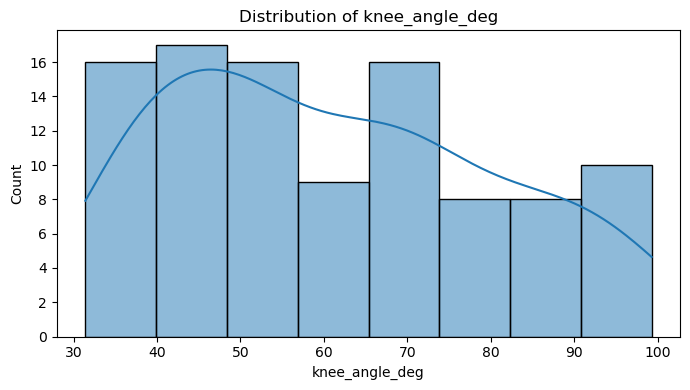

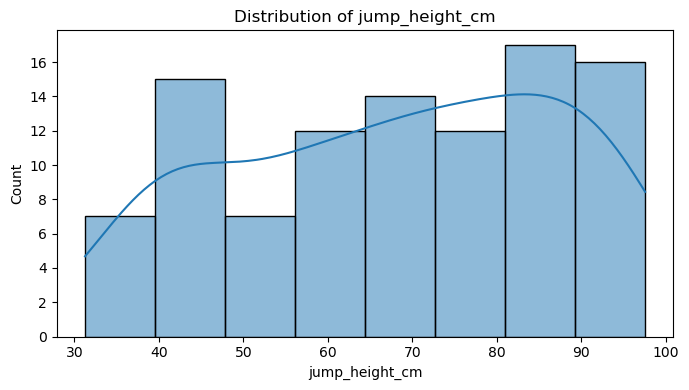

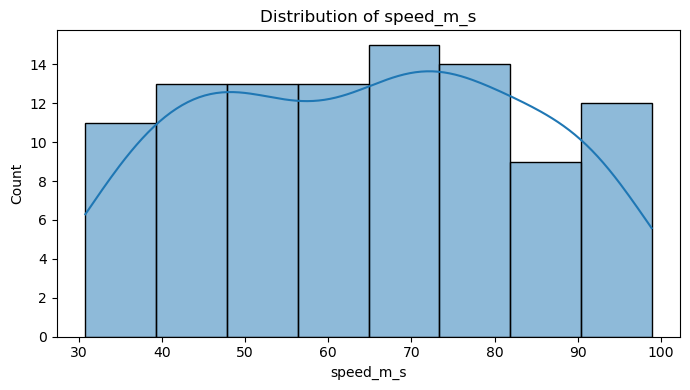

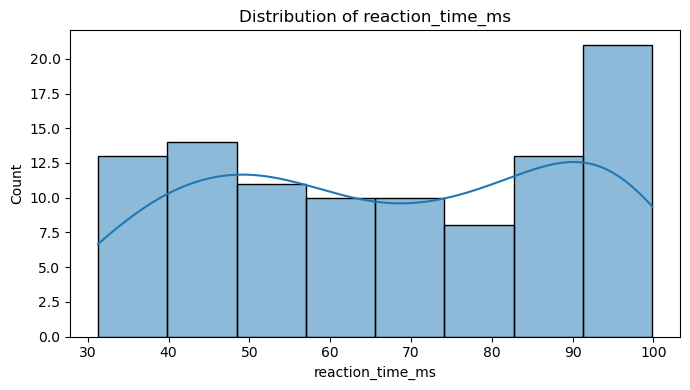

In [52]:
biomech_variables = ["knee_angle_deg", "jump_height_cm", "speed_m_s", "reaction_time_ms"]

for col in biomech_variables:
    plt.figure(figsize = (7,4))
    sns.histplot(data = basketball_df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

#### Knee Angle: There are very low knee angles (near 30 degrees) and very high knee angles (near 100 degrees) which are less common. Most players cluster around a knee angle of 48 degrees.
#### Jump Height: Most players cluster around a jump height of 85 cm. There is a spike though at the 40-50 bin.
#### Speed: Most players fall into the mid-range speed of 70 m/s
#### Reaction Time: The reaction‑time histogram shows a relatively flat distribution across most bins, with the KDE line staying between 7 and 10 counts. However, the final bin (90–100 ms) shows a noticeable spike to 20 players, suggesting a subgroup with slower reaction times.

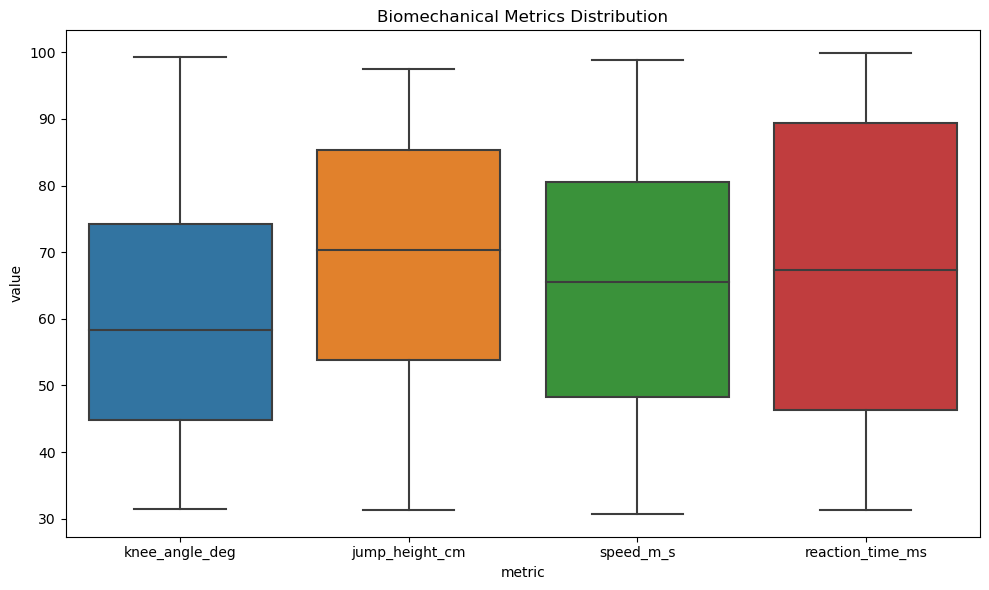

In [54]:
# Boxplots for injury status'
plt.figure(figsize = (10,6))
sns.boxplot(data = basketball_df.melt(value_vars = biomech_variables, var_name = "metric", value_name = "value"),
            x="metric", y="value")
plt.title("Biomechanical Metrics Distribution")
plt.tight_layout()
plt.show()

#### The boxplots show that each biomechanical variable has a distinct distribution across the player population. Knee angle is the most tightly clustered variable, while reaction time shows the greatest variability.  

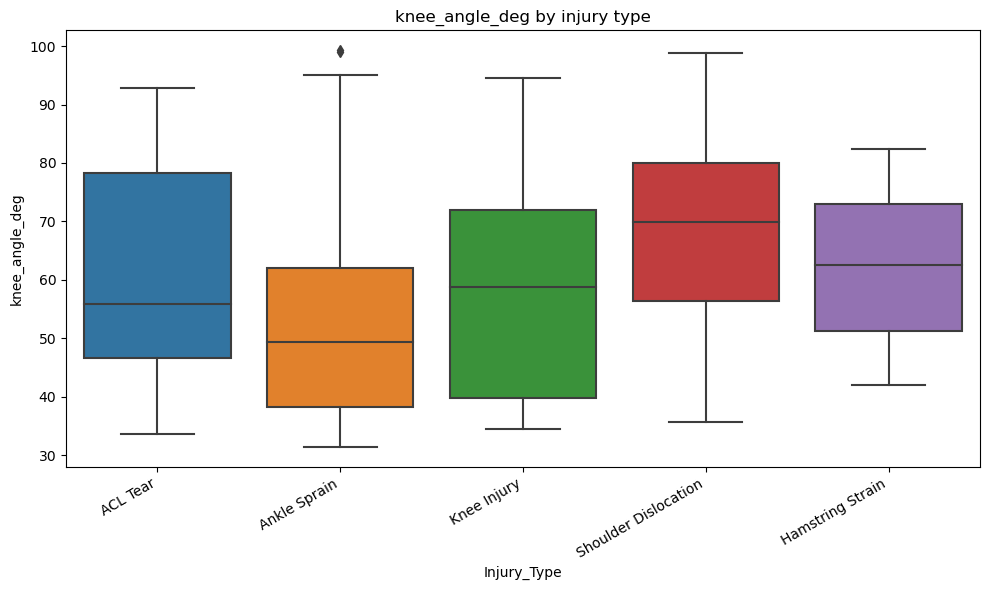

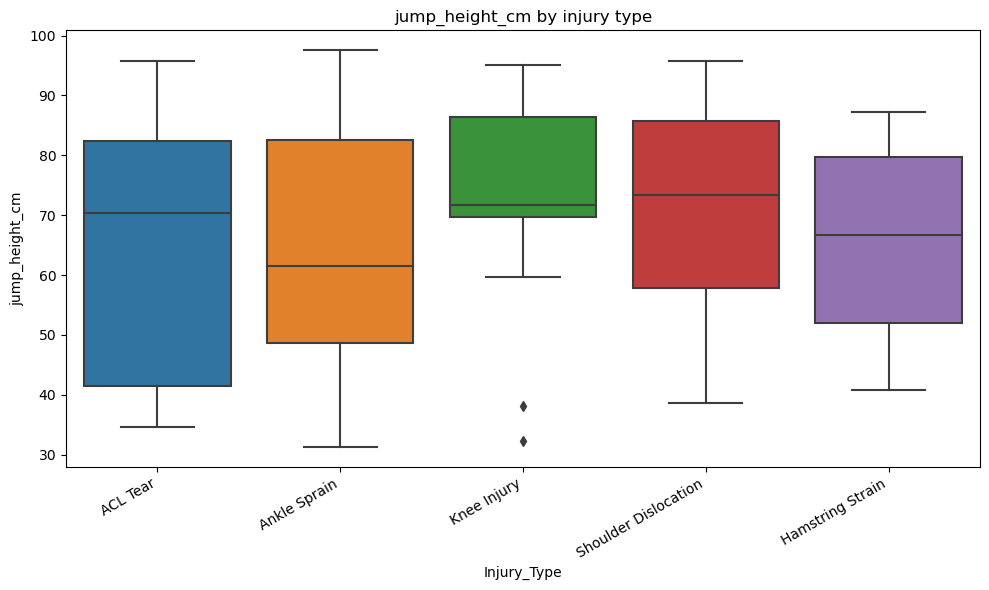

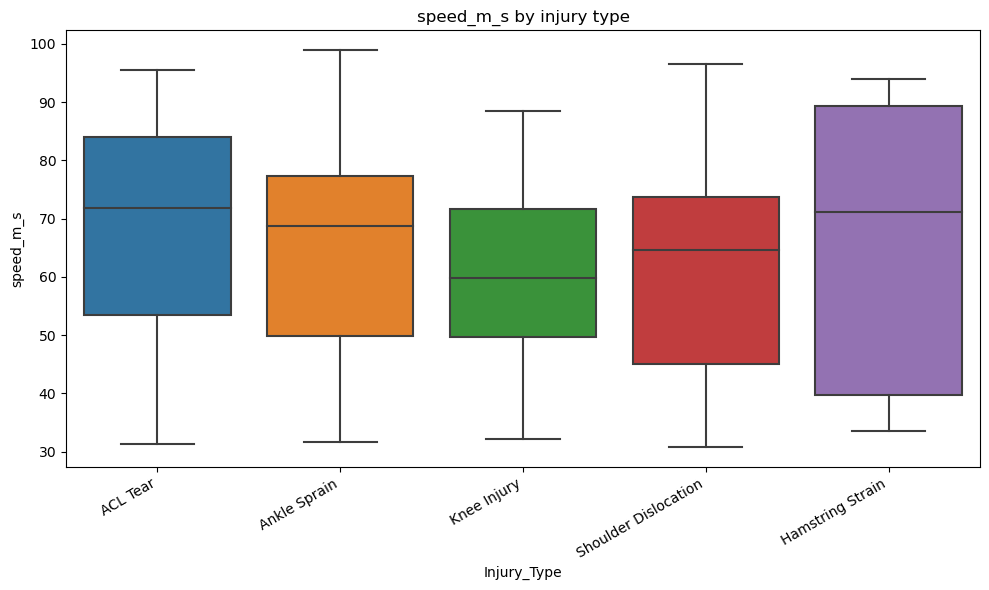

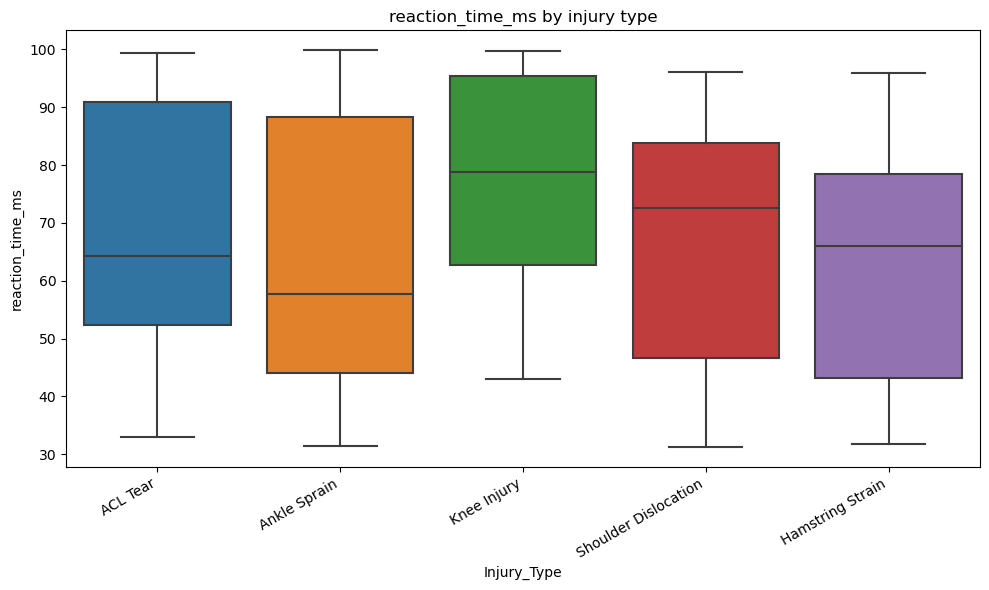

In [56]:
# Biomechanical variables vs injury type
# Which biomechanical variables are most strongly associated with each injury type?

for col in biomech_variables:
    plt.figure(figsize=(10,6))
    sns.boxplot(data = basketball_df, x="Injury_Type", y=col)
    plt.title(f"{col} by injury type")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

#### Knee Angle: Knee angle shows meaningful differences across injury types. Ankle sprains are associated with lower knee angles, while shoulder dislocations show the highest angle values. Hamstring strains and general knee injuries fall in the middle. These patterns suggest that reduced knee flexion may be linked to lower‑limb injury mechanisms, particularly ankle sprains. 
#### Jump Height: ACL tears and ankle sprains are associated with higher jump heights. General knee injuries show a high jump‑height cluster but also include low‑height outliers. Shoulder dislocations and hamstring strains fall in mid‑range values, reflecting that these injuries are less directly tied to jumping heights. Overall, jump height appears to be most strongly associated with lower‑limb injuries.
#### Speed: Speed varies across injury types. ACL tears and ankle sprains are associated with higher movement speeds. General knee injuries occur within a narrower, mid‑range speed band. Shoulder dislocations show moderate speeds. Hamstring strains display the widest speed range, with many cases clustering at high speeds, consistent with sprint‑related injury patterns. Overall, speed appears to be a key biomechanical variable for lower‑limb injuries, specifically hamstring injuries.
#### Reaction Time: Reaction time varies across injury types. ACL tears, ankle sprains, and general knee injuries show slower reaction times. In contrast, shoulder‑dislocation and hamstring‑strain cases show faster reaction times. These patterns indicate that slower reaction time may be a biomechanical risk factor for lower‑limb injuries.

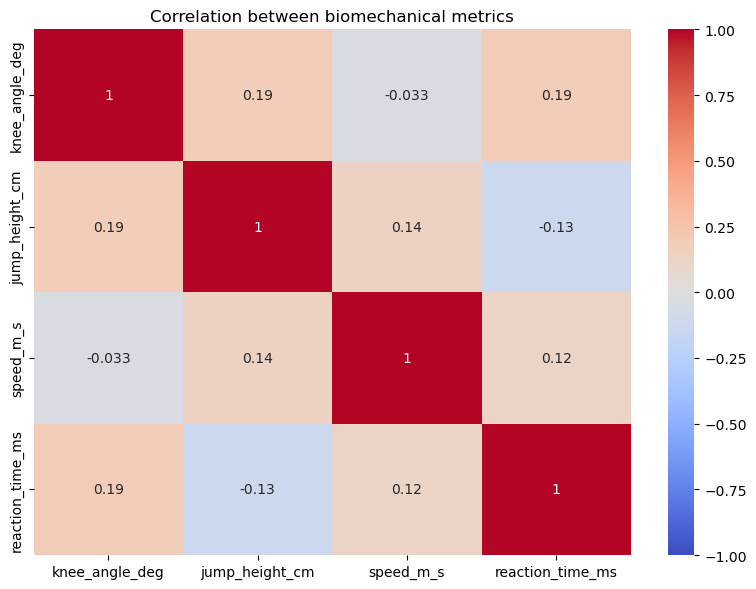

In [58]:
# Do specific biomechanical patterns correlate with certain injury types?

plt.figure(figsize=(8,6))
corr = basketball_df[biomech_variables].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between biomechanical metrics")
plt.tight_layout()
plt.show()

#### The correlation heatmap shows that the biomechanical variables have only weak relationships with one another, with no strong positive or negative correlations. No two biomechanical variables are strongly correlated with each other.

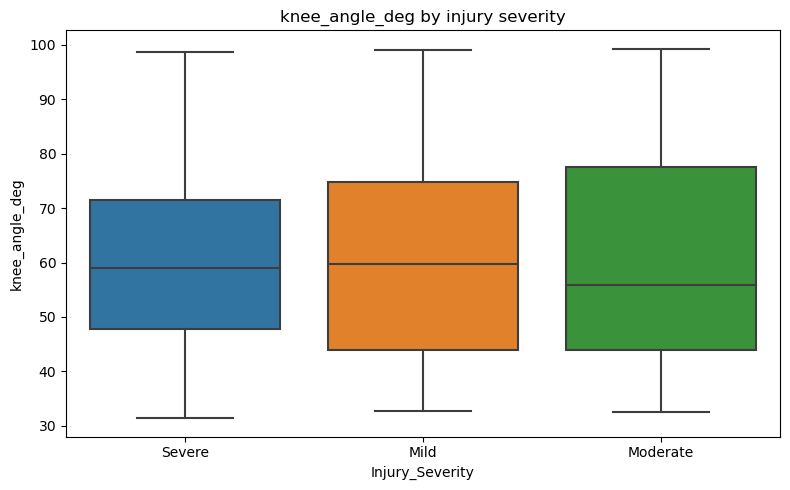

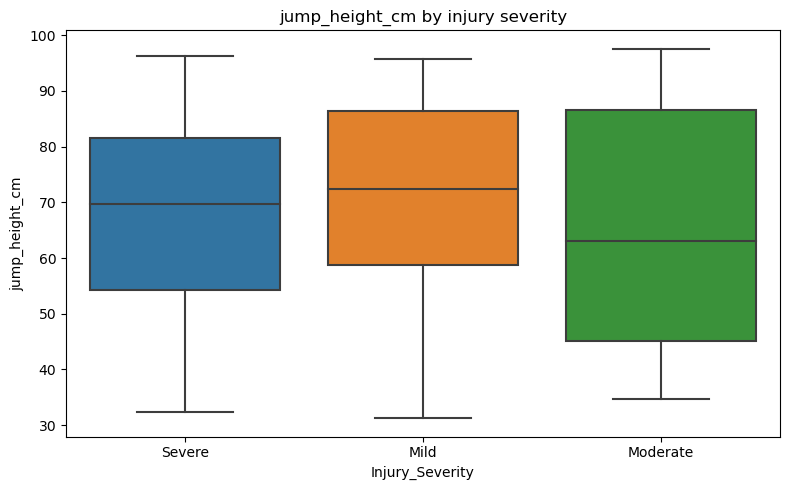

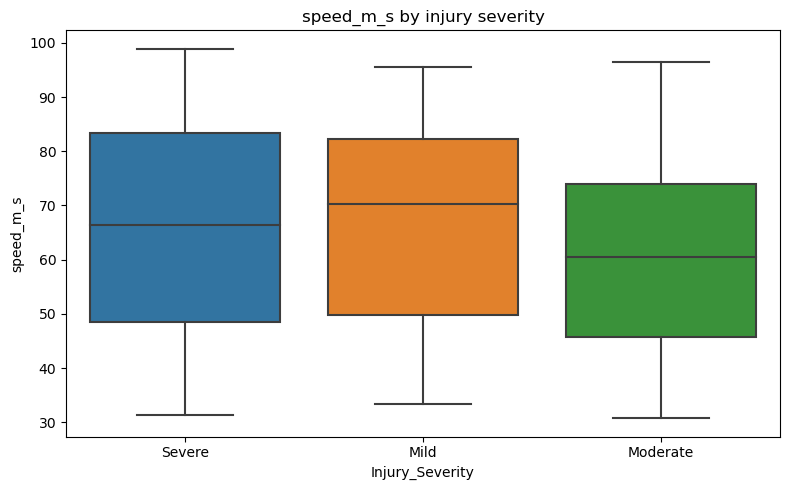

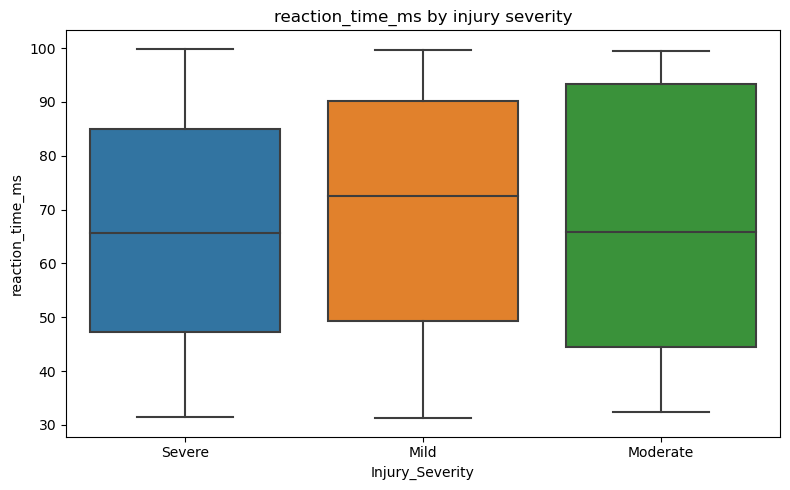

In [60]:
# Are specific biomechanical patterns more prevalent in high-severity injuries compared to low-severity ones?

for col in biomech_variables:
    plt.figure(figsize=(8,5))
    sns.boxplot(data = basketball_df, x="Injury_Severity", y=col)
    plt.title(f"{col} by injury severity")
    plt.tight_layout()
    plt.show()

#### Knee Angle: Knee angle does not appear to differentiate high‑severity injuries from low‑severity ones.
#### Jump Height: Severity is not driven by jump height extremes.
#### Speed: Speed does not show a strong or consistent relationship with injury severity.
#### Reaction Time: Reaction time is not a strong differentiator of injury severity, and high‑severity injuries are not associated with unusually fast or slow response times.

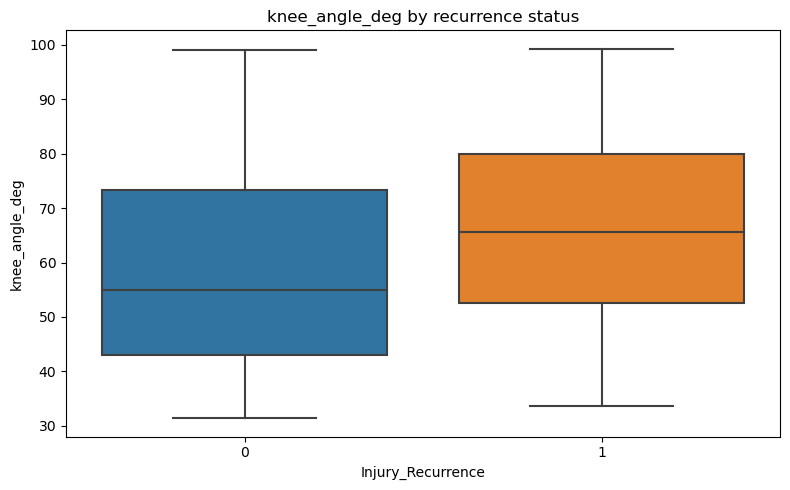

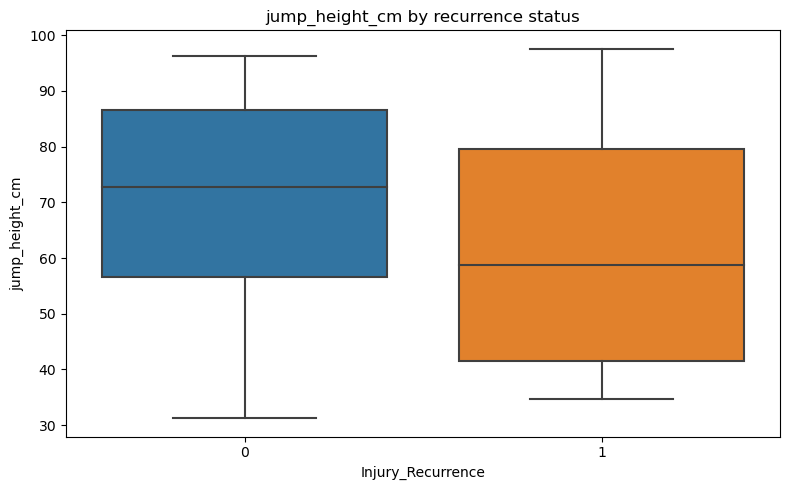

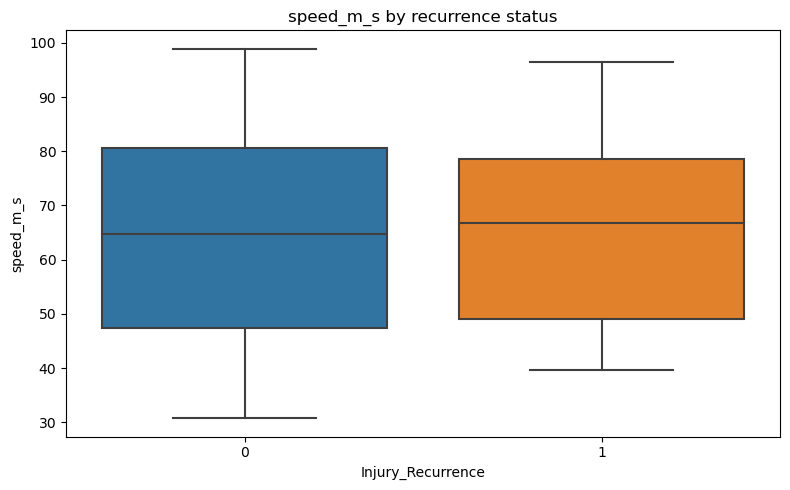

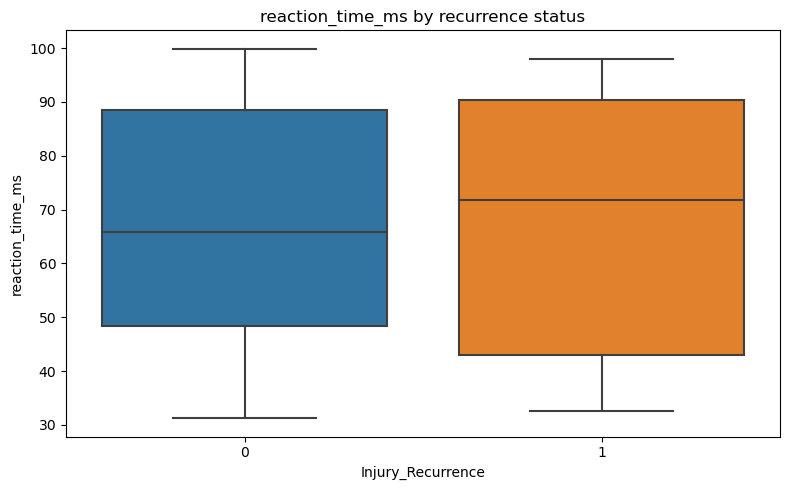

In [62]:
# Do athletes with recurrent injuries show distinct biomechanical patterns compared to first-time injuries?

for col in biomech_variables:
    plt.figure(figsize=(8,5))
    sns.boxplot(data = basketball_df, x="Injury_Recurrence", y=col)
    plt.title(f"{col} by recurrence status")
    plt.tight_layout()
    plt.show()

#### Knee Angle: Recurrent‑injury athletes tend to move with higher knee flexion.
#### Jump Height: Recurrent‑injury athletes show reduced jump heights.
#### Speed: Speed does not appear to differ meaningfully between first‑time and recurrent injuries.
#### Reaction Time: Reaction time shows no clear difference between first‑time and recurrent injuries.

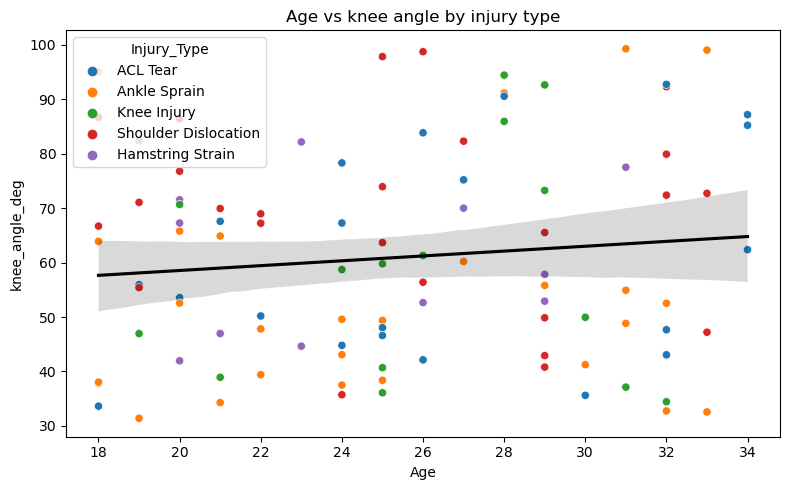

In [64]:
# Is age, height, or weight associated with specific biomechanical patterns linked to injury?
# Age	Height_cm	Weight_kg	

plt.figure(figsize=(8,5))
sns.scatterplot(data = basketball_df, x="Age", y="knee_angle_deg", hue="Injury_Type")
sns.regplot(data = basketball_df, x="Age", y="knee_angle_deg", scatter=False, color="black")
plt.title("Age vs knee angle by injury type")
plt.tight_layout()
plt.show()

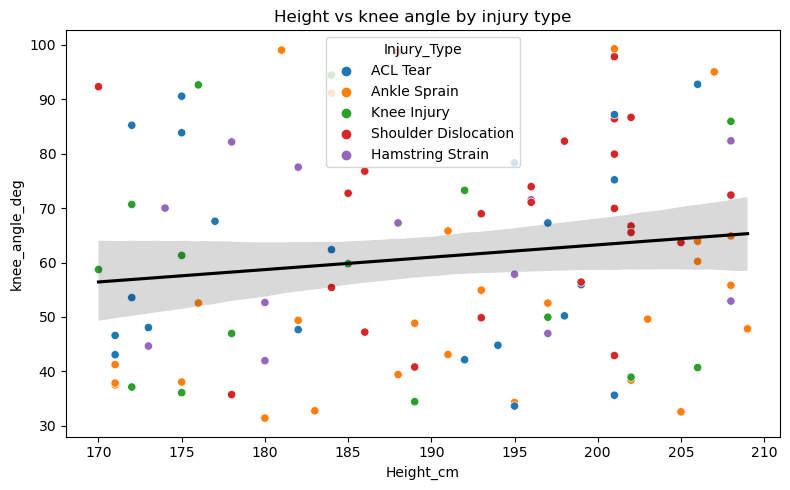

In [65]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = basketball_df, x="Height_cm", y="knee_angle_deg", hue="Injury_Type")
sns.regplot(data = basketball_df, x="Height_cm", y="knee_angle_deg", scatter=False, color="black")
plt.title("Height vs knee angle by injury type")
plt.tight_layout()
plt.show()

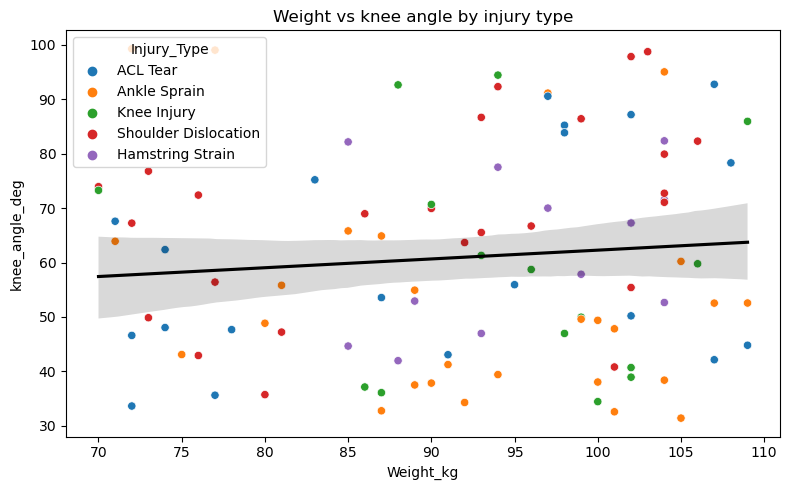

In [66]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = basketball_df, x="Weight_kg", y="knee_angle_deg", hue="Injury_Type")
sns.regplot(data = basketball_df, x="Weight_kg", y="knee_angle_deg", scatter=False, color="black")
plt.title("Weight vs knee angle by injury type")
plt.tight_layout()
plt.show()

#### Age, height, and weight showed only weak associations with knee‑angle biomechanics. Regression lines rise slightly across each demographic range. There is some clustering of ankle sprains among the higher-weight demographic. 

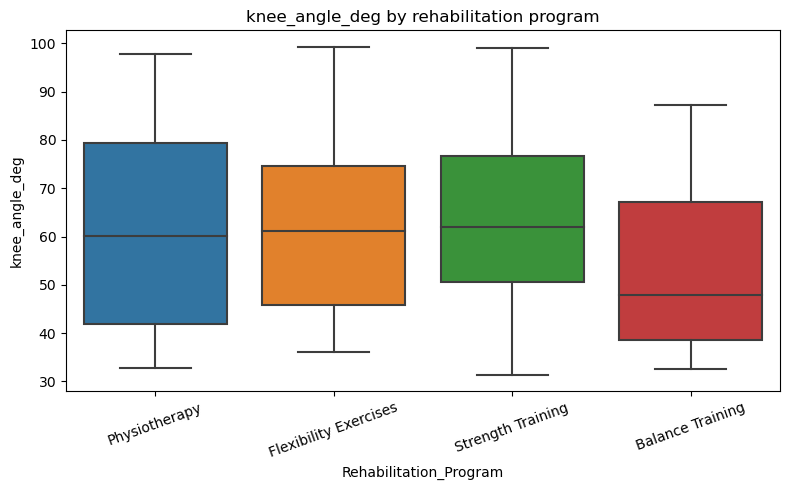

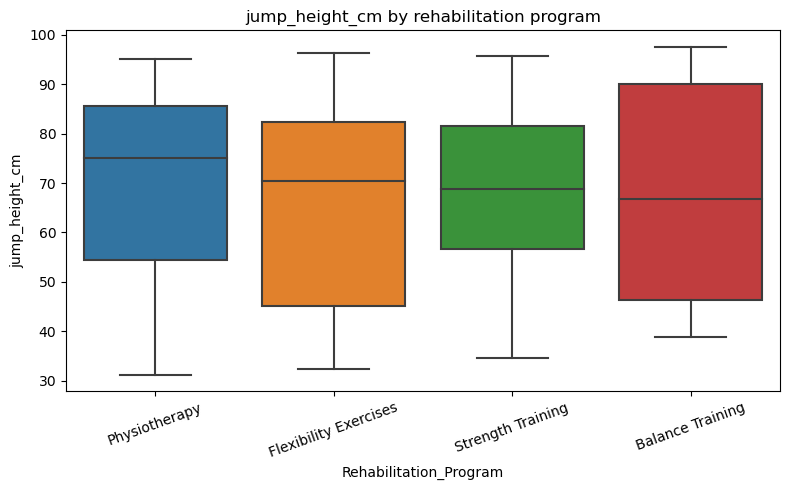

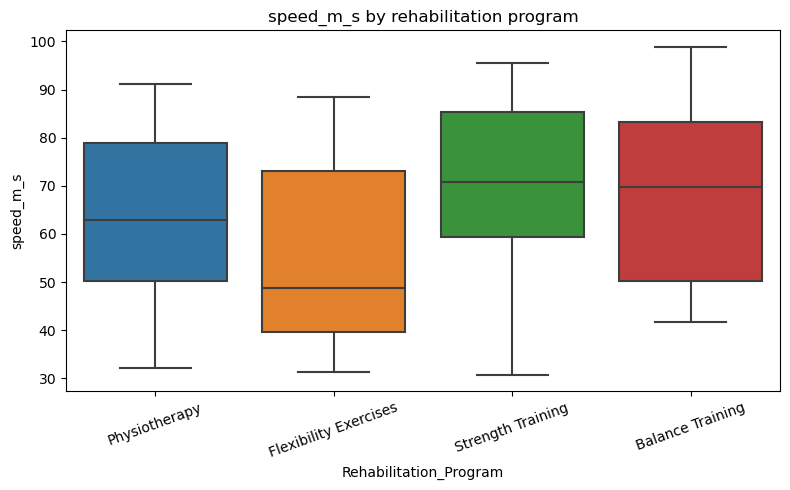

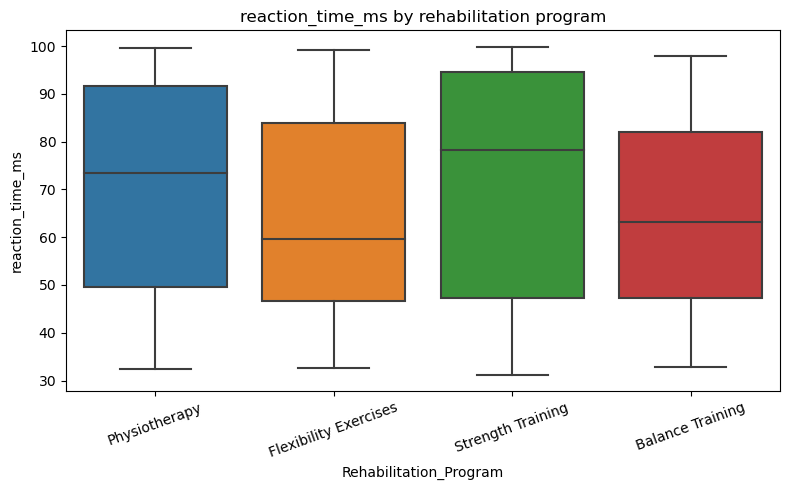

In [68]:
# How do different rehabilitation programs (physiotherapy, strength training, balance training) influence post-injury biomechanical patterns?

for col in biomech_variables:
    plt.figure(figsize=(8,5))
    sns.boxplot(data = basketball_df, x="Rehabilitation_Program", y=col)
    plt.title(f"{col} by rehabilitation program")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

#### Across all rehabilitation programs, biomechanical differences were small, indicating that no single program produced a dramatically distinct post‑injury movement pattern. However, subtle trends emerged. Balance and flexibility training showed greater variability in jump height, physiotherapy produced the widest range of knee‑angle mechanics, and strength training and physiotherapy showed the most consistent speed values. Reaction‑time outcomes were most variable in the strength‑training group. 

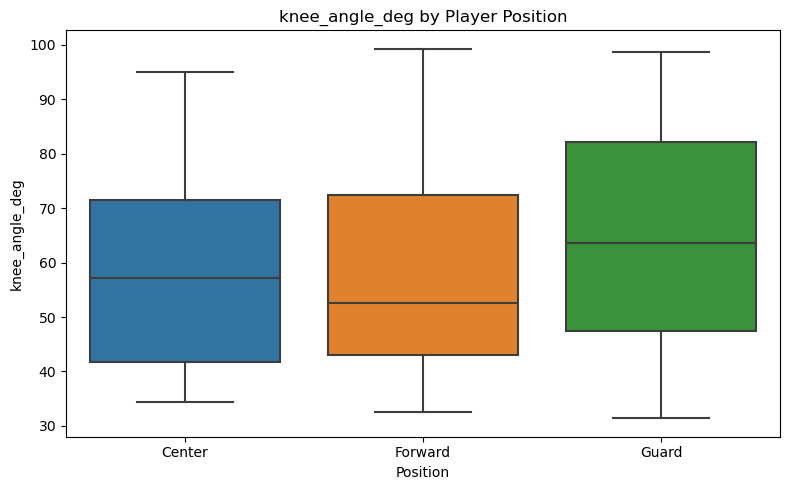

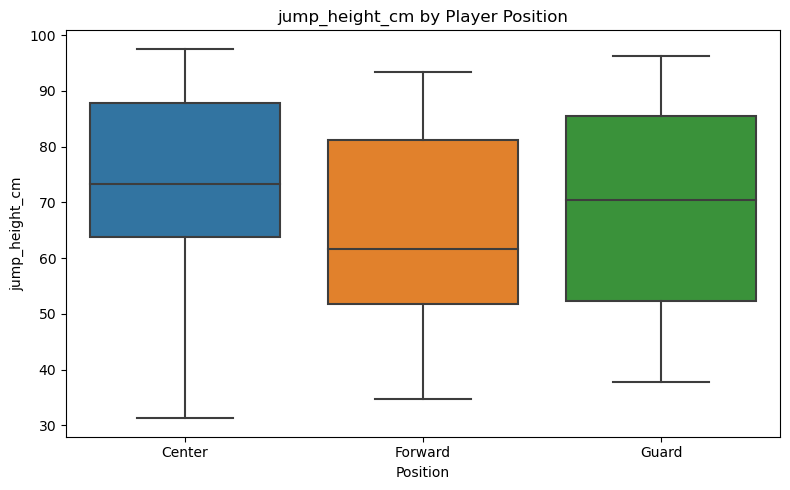

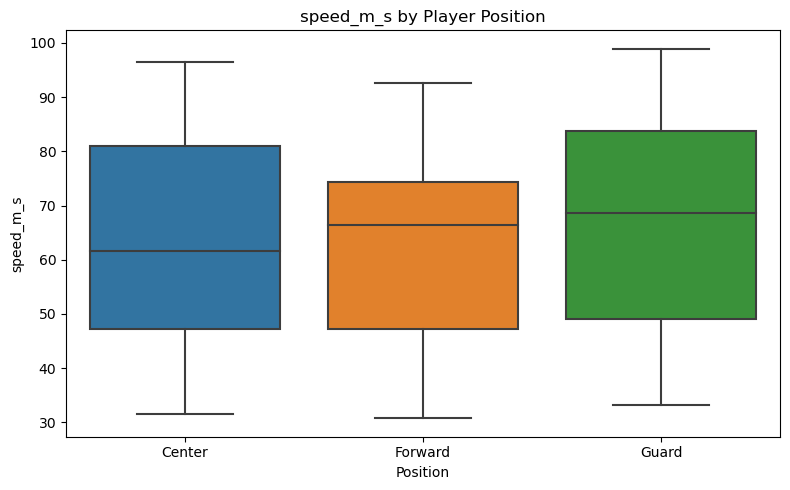

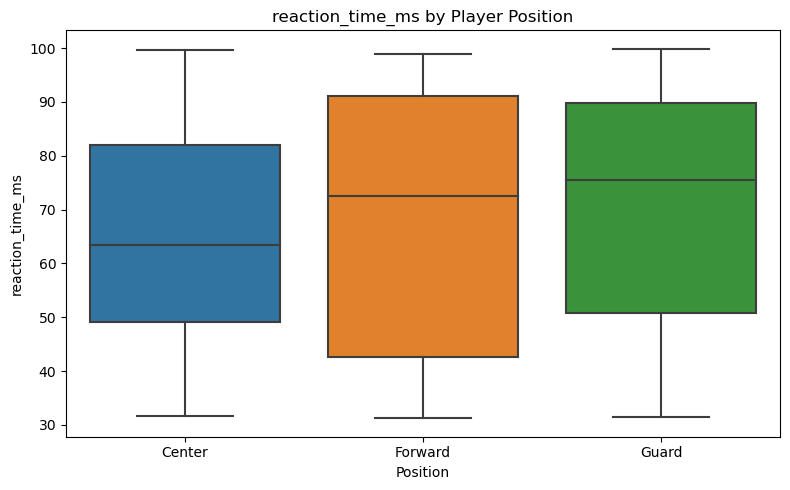

In [70]:
# Do biomechanical risk profiles differ by player position (guard, forward, center)?

for col in biomech_variables:
    plt.figure(figsize=(8,5))
    sns.boxplot(data = basketball_df, x="Position", y=col)
    plt.title(f"{col} by Player Position")
    plt.tight_layout()
    plt.show()

#### Knee Angle: Guards show the widest knee‑angle range.
#### Jump Height: Guards reach high values, while forwards sit lower overall.
#### Speed: Guards are the fastest group. Centers and forwards have similar lower ranges.
#### Reaction Time: Forwards show the widest reaction‑time range.

C:\Users\rmtol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


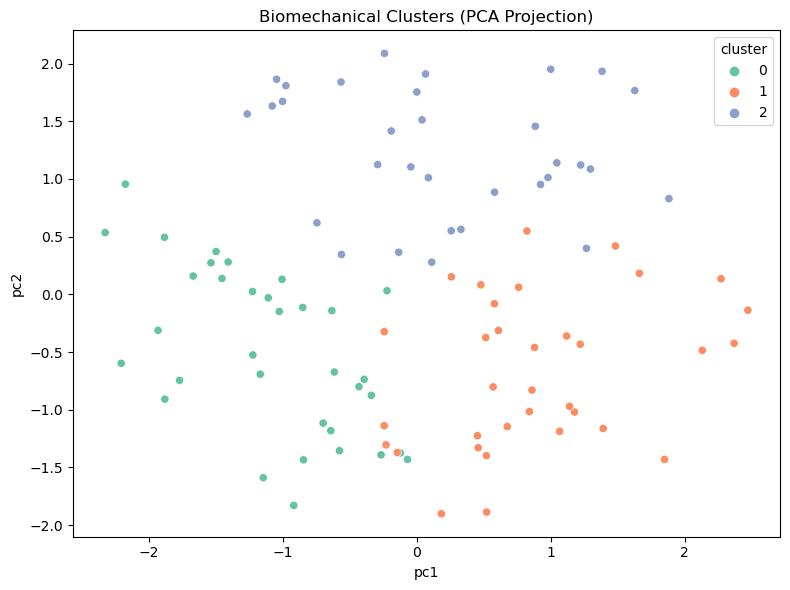

In [72]:
# Clustering biomechanical patterns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = basketball_df[biomech_variables].dropna()
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
basketball_df["cluster"] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
pca_vals = pca.fit_transform(X_scaled)
basketball_df["pc1"], basketball_df["pc2"] = pca_vals[:,0], pca_vals[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data = basketball_df, x="pc1", y="pc2", hue="cluster", palette="Set2")
plt.title("Biomechanical Clusters (PCA Projection)")
plt.tight_layout()
plt.show()

#### The PCA‑based clustering reveals three distinct biomechanical profiles. Each cluster occupies a different region of the biomechanical movement space, indicating that players with similar movement patterns are grouped together. These clusters can be compared with injury types to determine whether specific injuries are associated with particular biomechanical patterns. 

In [74]:
pd.crosstab(basketball_df["cluster"], basketball_df["Injury_Type"])

Injury_Type,ACL Tear,Ankle Sprain,Hamstring Strain,Knee Injury,Shoulder Dislocation
cluster,,,,,
0,6,12,6,3,7
1,8,6,4,6,10
2,7,9,2,6,8


#### Cluster 0 appears to represent athletes whose biomechanical patterns are strongly associated with ankle sprains. This cluster may reflect movement profiles involving reduced knee flexion, moderate jump height, or landing mechanics that increase ankle loading.
#### Cluster 1 includes a high number of ACL tears and shoulder dislocations. This suggests a biomechanical profile characterized by high speed, high jump height, and explosive movement patterns. These athletes may experience both lower‑limb injuries (ACL) and upper‑body injuries (shoulder) due to high‑force, high‑velocity actions.
#### Cluster 2 shows a more balanced distribution of injuries but notably contains very few hamstring strains. This suggests a biomechanical profile that does not strongly involve the high‑speed sprinting mechanics typically associated with hamstring injuries.

#### Do specific biomechanical patterns correlate with certain injury types? Yes, the clustering analysis shows that certain injury types are more common within specific biomechanical profiles. Cluster 0 is dominated by ankle sprains, Cluster 1 shows high rates of ACL tears and shoulder dislocations, and Cluster 2 contains very few hamstring strains. These patterns indicate that injury risk is influenced by combinations of biomechanical variables.